In [1]:
_repo_root = !git rev-parse --show-toplevel
%cd -q {_repo_root[0]}
del _repo_root

# Univariate fitting

Loads, validates, summarizes, and plots persisted univariate experiment results.
Curves show median test RMSE across seeds; shaded bands span the 25th to 75th percentiles.

In [2]:
import matplotlib as mpl
import pandas as pd

from paper.experiments import synthetic, univariate
from paper.plotting import (
    plot_general_scaling,
    plot_monotone_scaling,
    plot_target_gallery,
)
from paper.targets import TargetSpec

mpl.rcParams["figure.dpi"] = 140

In [3]:
profile_name = "full"
profile = univariate.PROFILES[profile_name]
raw_path = synthetic.default_raw_path("univariate", profile_name)

In [4]:
if not raw_path.exists():
    raise FileNotFoundError(
        f"{raw_path} does not exist; run paper.experiments.univariate first"
    )

raw = pd.read_csv(raw_path)
synthetic.validate_raw(raw, profile)
summary = synthetic.summarize_results(raw)
summary.head()

,target_kind,complexity,noise_std,model,dim,batch_size,train_size,selected_lr,median_test_rmse,q25_test_rmse,q75_test_rmse,n
0,general,5,0.0,unconstrained,5,32,32,0.1,1.106884,0.740479,1.603009,96
1,general,5,0.0,unconstrained,5,32,64,0.1,0.897321,0.590225,1.327749,96
2,general,5,0.0,unconstrained,5,32,160,0.1,0.574980,0.379431,0.891566,96
3,general,5,0.0,unconstrained,5,32,320,0.1,0.419482,0.261517,0.578556,96
4,general,5,0.0,unconstrained,5,32,640,0.1,0.262496,0.161277,0.421674,96


## General targets

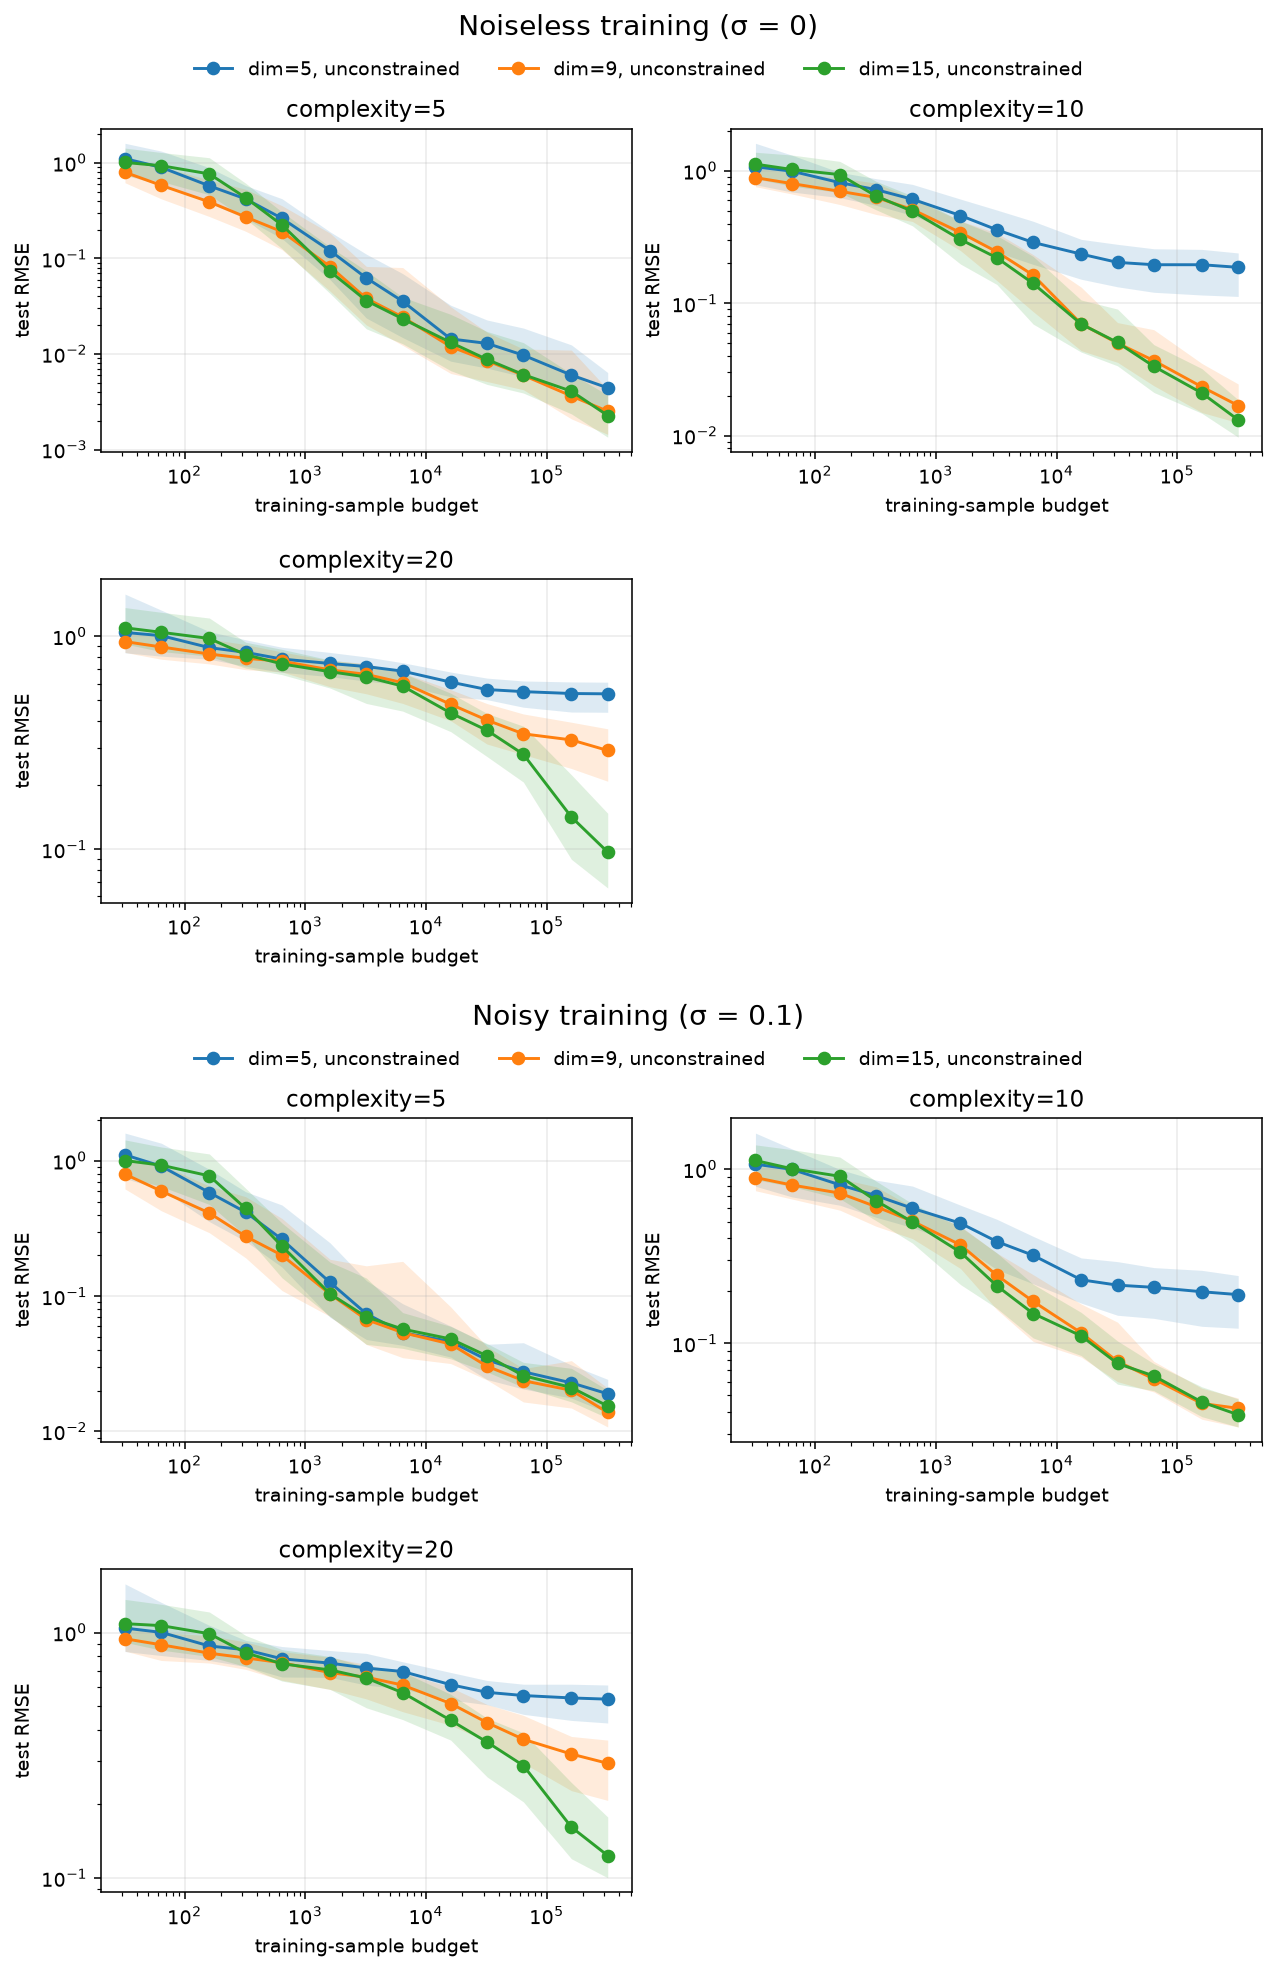

In [5]:
general_summary = summary.loc[summary["target_kind"] == "general"]
plot_general_scaling(general_summary);

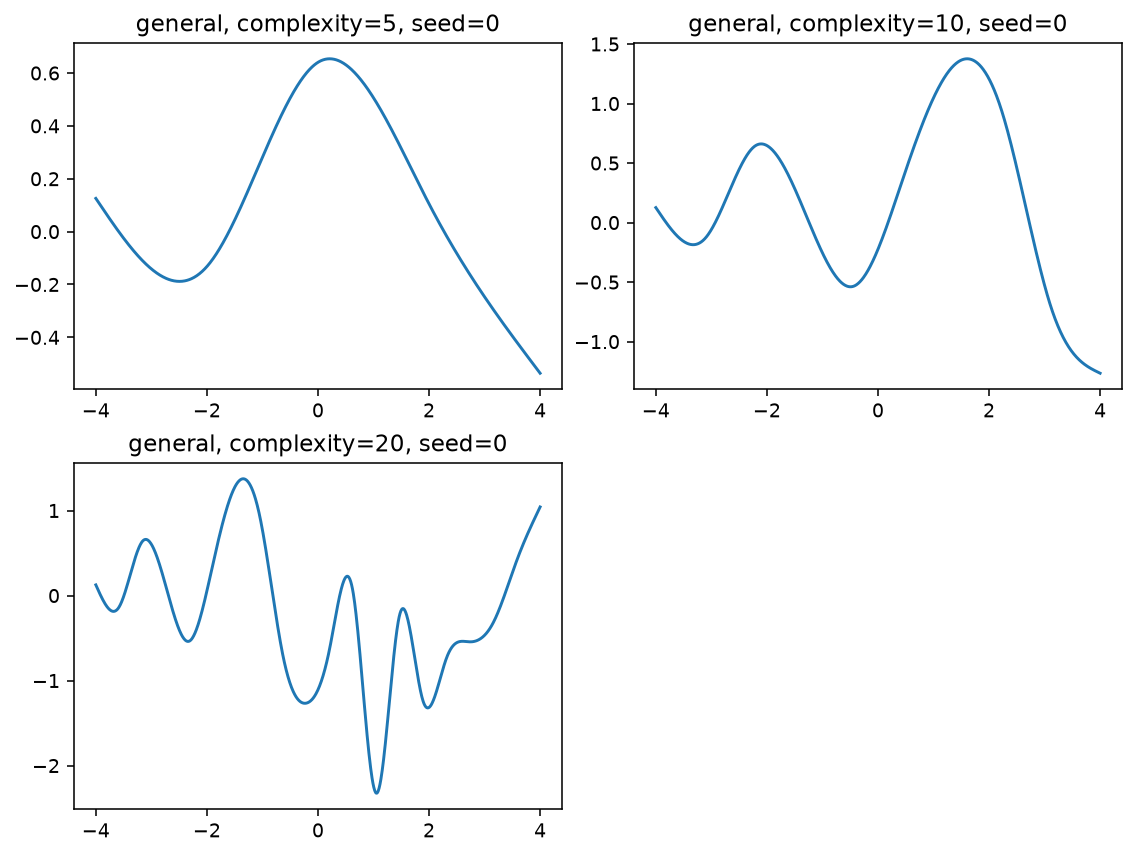

In [6]:
plot_target_gallery([
    TargetSpec(kind="general", complexity=complexity, seed=0)
    for complexity in sorted(general_summary["complexity"].unique())
]);

## Monotone targets

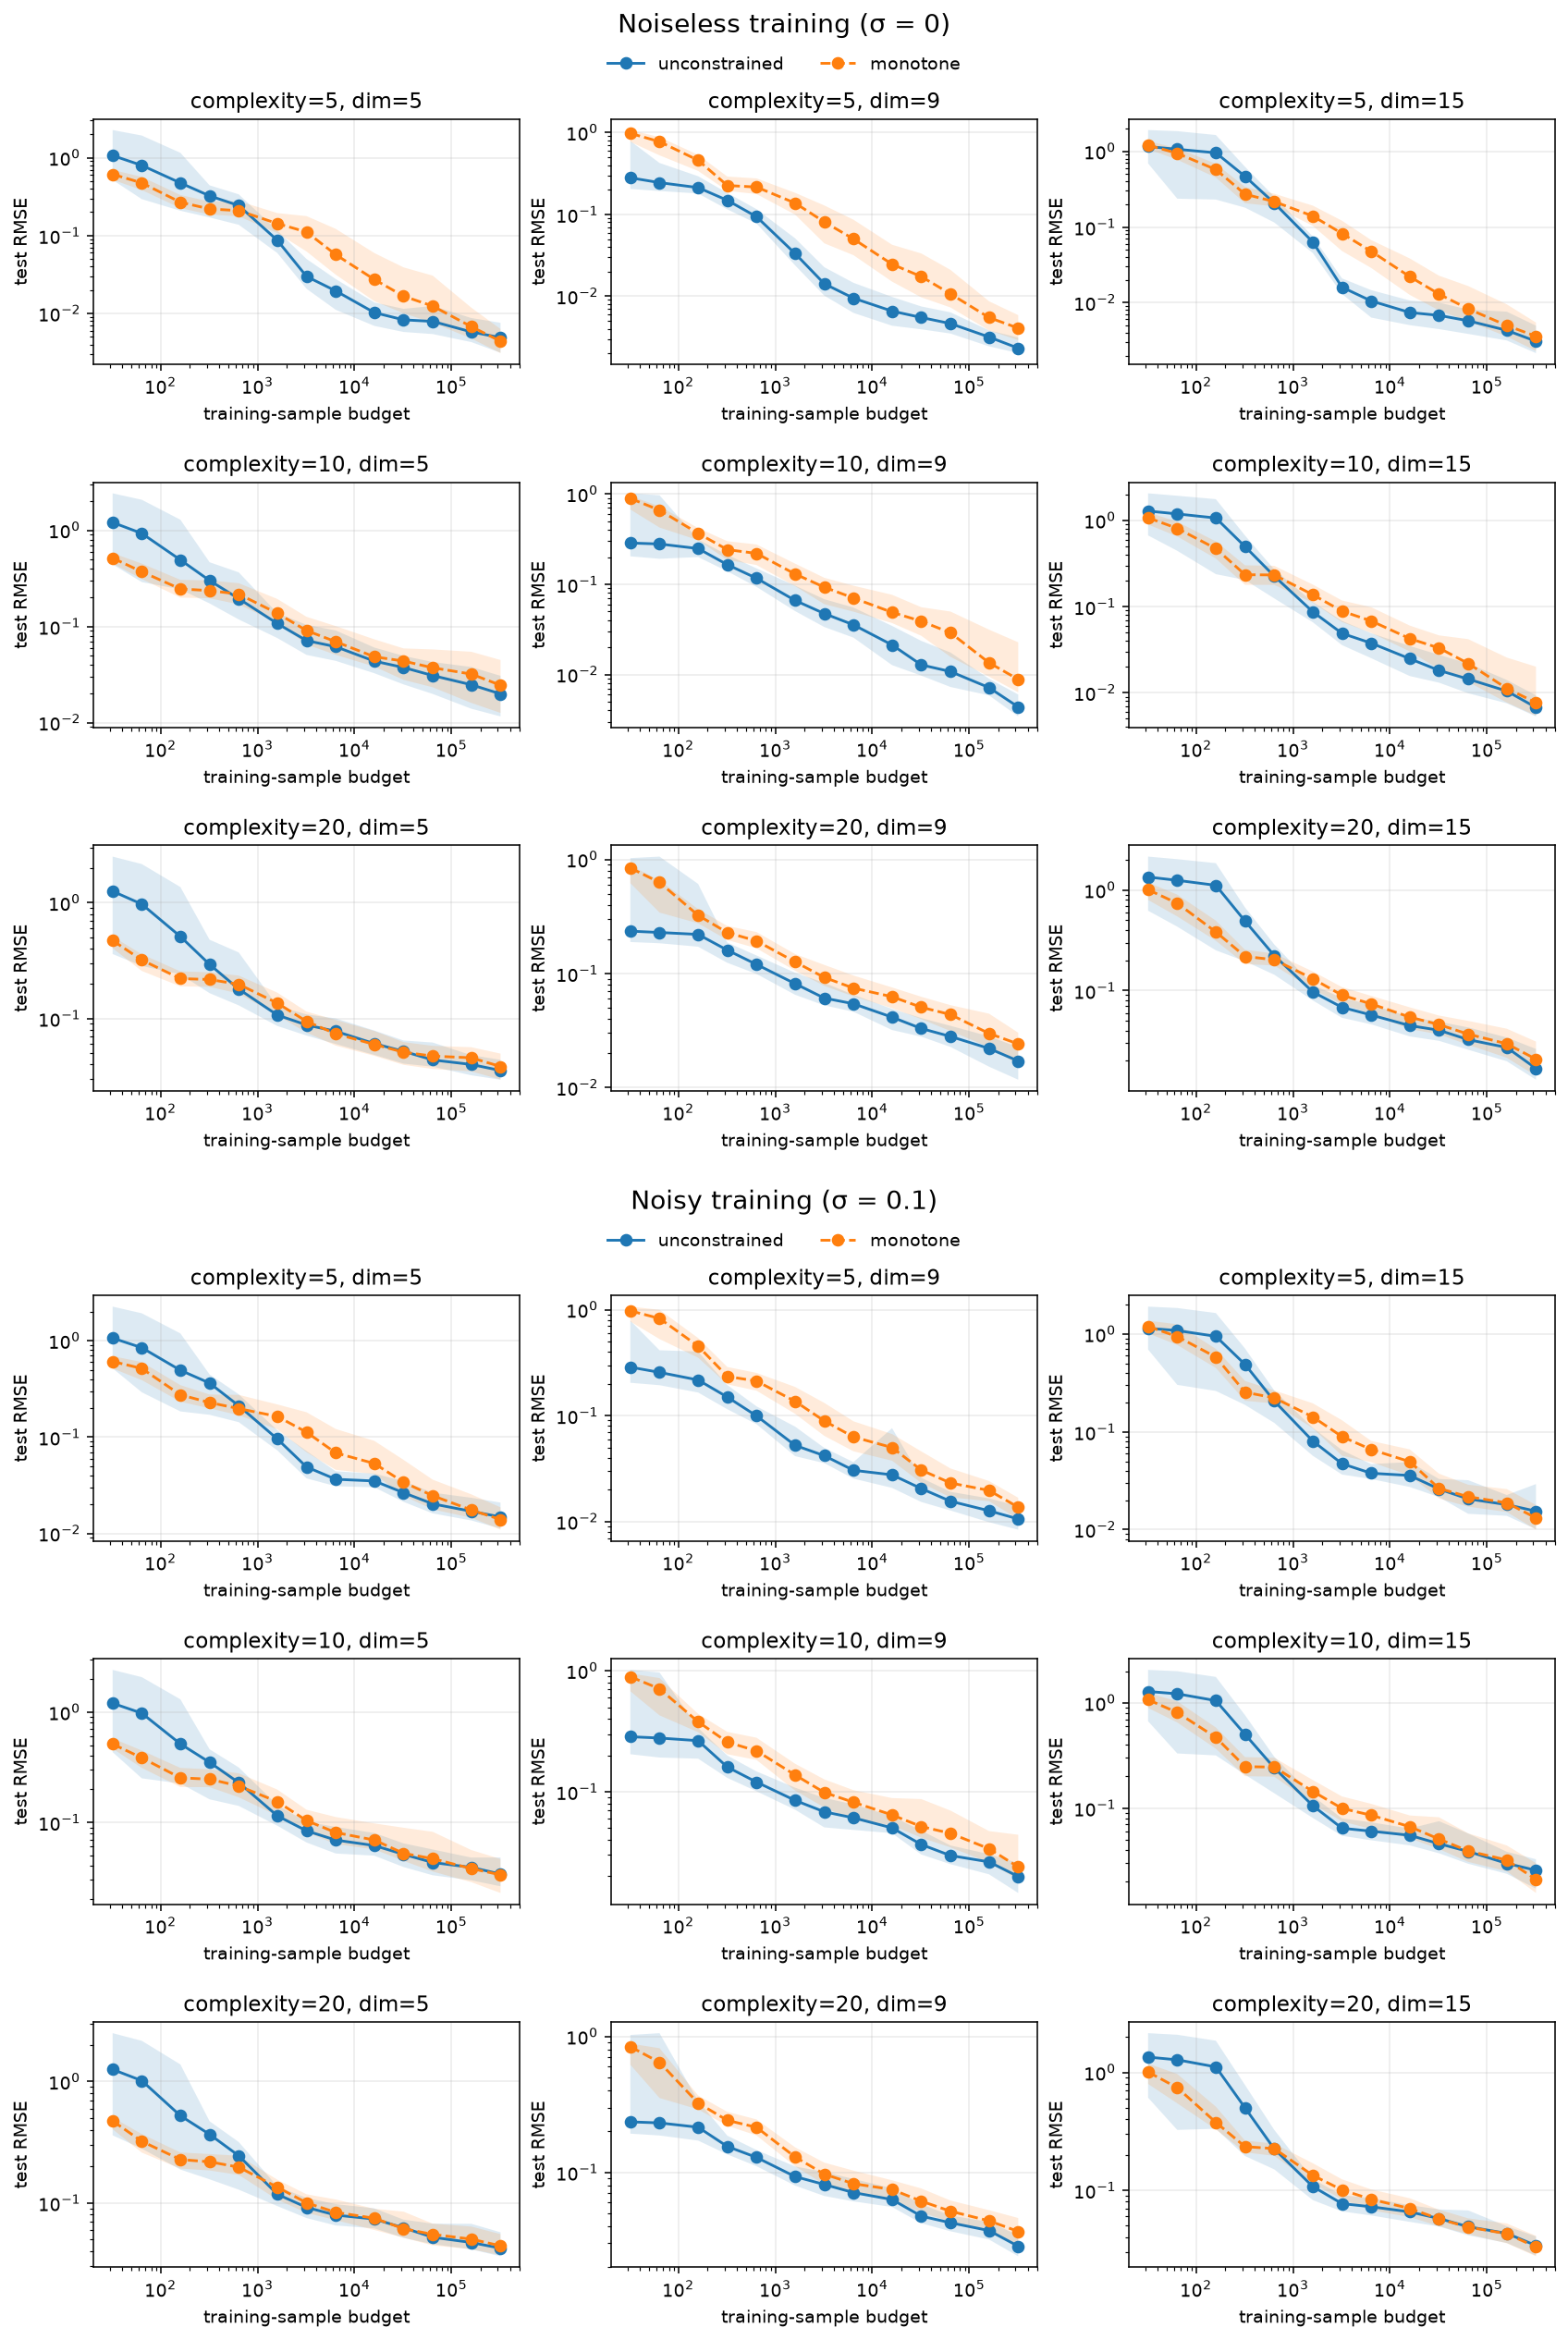

In [7]:
monotone_summary = summary.loc[summary["target_kind"] == "monotone"]
plot_monotone_scaling(monotone_summary);

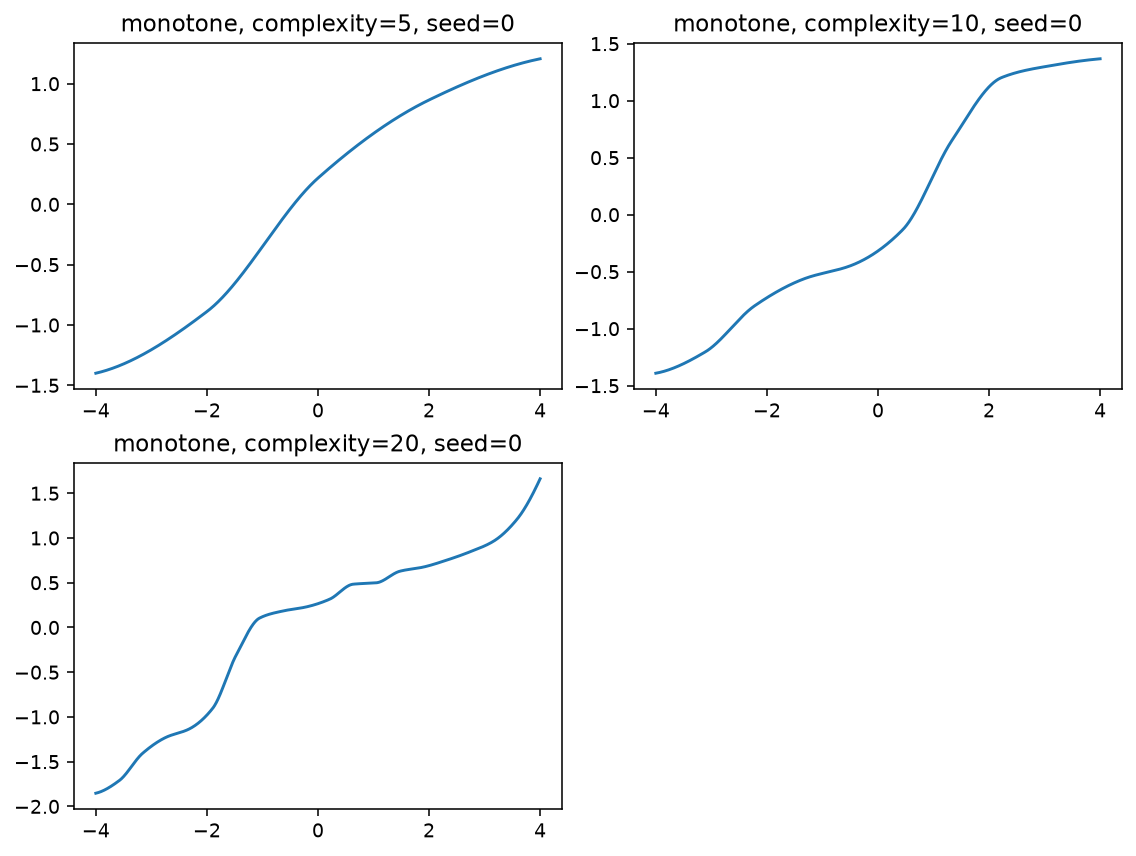

In [8]:
plot_target_gallery([
    TargetSpec(kind="monotone", complexity=complexity, seed=0)
    for complexity in sorted(monotone_summary["complexity"].unique())
]);